# Testing and Analysing the Power Spectra

## Converting to 1D power spectra

We can collapse one dimension by averaging across it.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import os

npz_templates = "/home/olivia/oskareor.data/2dps_npz_templates/"

npz = np.load(npz_templates+"flat.npz")

npz.keys()

KeysView(NpzFile '/home/olivia/oskareor.data/2dps_npz_templates/flat.npz' with keys: k_perp, k_parr, twoD_power, weights)

(50, 48) (50, 48) (48,) (50,)
[0.01325809 0.01988713 0.02651618 0.03314522 0.03977427 0.04640331
 0.05303236 0.0596614  0.06629044 0.07291949 0.07954853 0.08617758
 0.09280662 0.09943567 0.10606471 0.11269375 0.1193228  0.12595184
 0.13258089 0.13920993 0.14583898 0.15246802 0.15909707 0.16572611
 0.17235515 0.1789842  0.18561324 0.19224229 0.19887133 0.20550038
 0.21212942 0.21875847 0.22538751 0.23201655 0.2386456  0.24527464
 0.25190369 0.25853273 0.26516178 0.27179082 0.27841986 0.28504891
 0.29167795 0.298307   0.30493604 0.31156509 0.31819413 0.32482318]


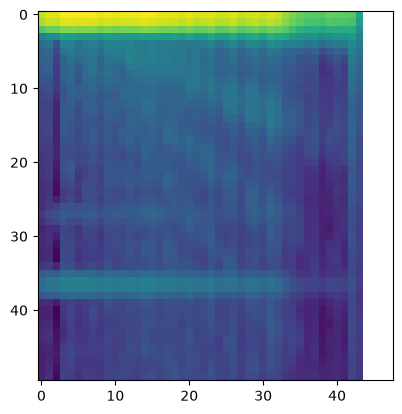

In [2]:
print(npz['twoD_power'].shape, npz['weights'].shape, npz['k_perp'].shape, npz['k_parr'].shape)
print(npz['k_perp'])
plt.imshow(npz['twoD_power'] * npz['weights'], norm="log")

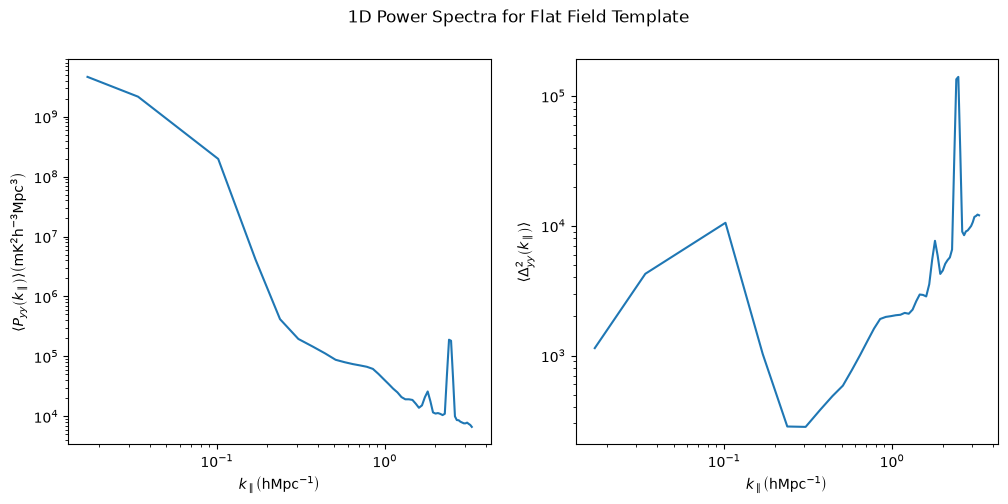

In [3]:
sdps = np.mean(npz['twoD_power'] * npz['weights'], axis=1)

dyy = (npz['k_parr'] ** 3) * sdps / (2 * np.pi ** 2)

fig, ax = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches((12, 5))
fig.suptitle("1D Power Spectra for Flat Field Template")
ax[0].loglog(npz['k_parr'], sdps)
ax[0].set_xlabel(r"$k_{\parallel} \left(\mathrm{h}\mathrm{Mpc}^{-1}\right)$")
ax[0].set_ylabel(r"$\langle P_{yy} \left(k_\parallel\right)\rangle\left(\mathrm{mK}^2\mathrm{h}^{-3}\mathrm{Mpc}^3\right)$")
ax[1].loglog(npz['k_parr'], dyy)
ax[1].set_xlabel(r"$k_{\parallel} \left(\mathrm{h}\mathrm{Mpc}^{-1}\right)$")
ax[1].set_ylabel(r"$\langle\Delta_{yy}^2 \left(k_\parallel\right) \rangle$")
plt.show()


flat_corr = dyy

## Testing the Template outputs

Comparing all inputs with the flat field.

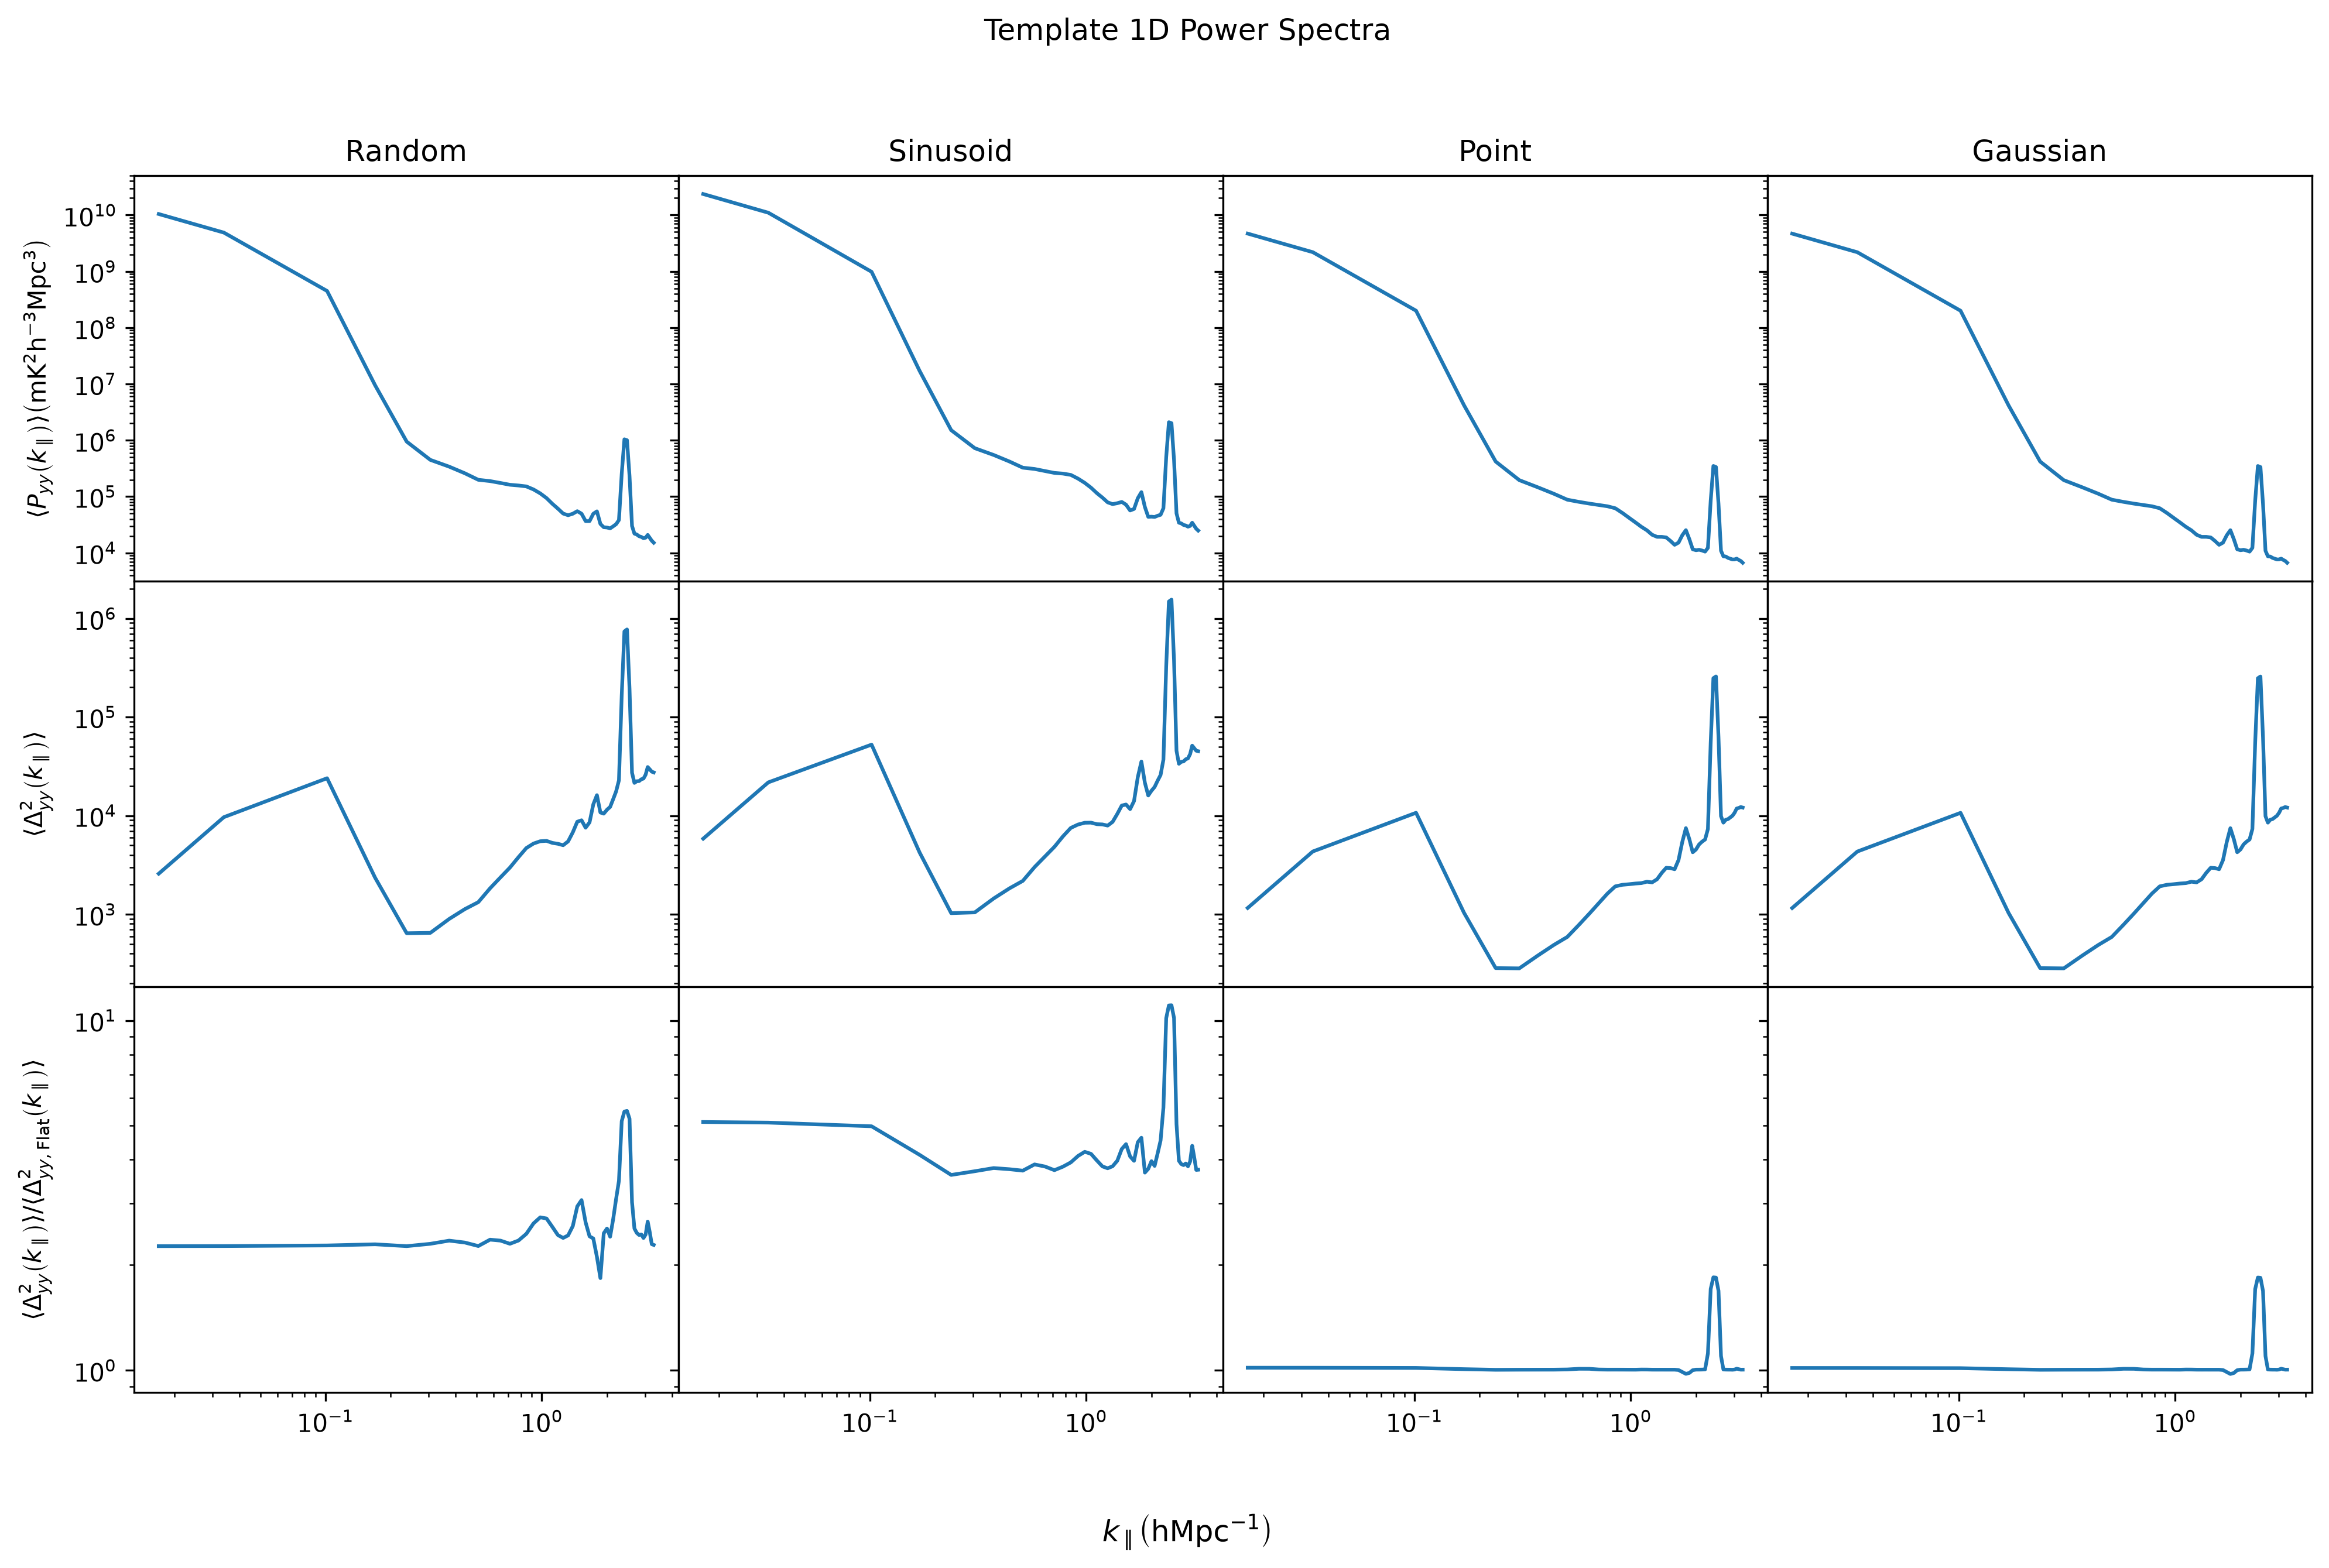

In [4]:
npz_files = os.listdir(npz_templates)
npz_files.remove("flat.npz")
npz_files.remove("dark.npz")

ntemp = len(npz_files)
i = 0

fig, ax = plt.subplots(nrows=3, ncols=ntemp, sharex=True, sharey='row', dpi=300)
fig.set_size_inches((4*(ntemp), 9))
fig.suptitle("Template 1D Power Spectra")

fig.supxlabel(r"$k_{\parallel} \left(\mathrm{h}\mathrm{Mpc}^{-1}\right)$")

ax[0, 0].set_ylabel(r"$\langle P_{yy} \left(k_\parallel\right)\rangle\left(\mathrm{mK}^2\mathrm{h}^{-3}\mathrm{Mpc}^3\right)$")
ax[1, 0].set_ylabel(r"$\langle\Delta_{yy}^2 \left(k_\parallel\right)\rangle$")
ax[2, 0].set_ylabel(r"$\langle\Delta_{yy}^2 \left(k_\parallel\right)\rangle / \langle\Delta_{yy, \mathrm{Flat}}^2 \left(k_\parallel\right)\rangle$")

for npzf in npz_files:
    # Load npz file
    npz = np.load(npz_templates+npzf)
    
    # Flatten power spectra
    sdps = np.mean(npz['twoD_power'] * npz['weights'], axis=1)
    dyy = (npz['k_parr'] ** 3) * sdps / (2 * np.pi ** 2)
    
    # Plot x title
    ax[0, i].set_title(npzf[0:-4].capitalize())
    
    # Plot uncorrected Pyy
    ax[0, i].loglog(npz['k_parr'], sdps)
    
    # Plot uncorrected Dyy
    ax[1, i].loglog(npz['k_parr'], dyy)
    
    # Plot corrected Dyy
    ax[2, i].loglog(npz['k_parr'], dyy / flat_corr)
    
    # Increment
    i = i + 1

fig.align_xlabels()
fig.align_ylabels()

# Remove all spacing between subplots.
fig.subplots_adjust(wspace=0, hspace=0)

plt.show()
    